In [2]:
import sys, os
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']='.9'
import dill
import matplotlib

import matplotlib.pyplot as pl
# set latex to false:
pl.rcParams['text.usetex'] = True
%load_ext autoreload
%autoreload 2
import pathlib
import numpy as np
import getdist
from getdist import plots, MCSamples
from getdist.gaussian_mixtures import MixtureND
%matplotlib inline








In [3]:
import pickle as pk
import dill as dill
import numpy as np
import matplotlib.pyplot as pl
import jax.numpy as jnp
pl.rc('text', usetex=True)
%matplotlib inline
import os

import getdist
from getdist import plots, MCSamples




def get_MC_samps_FoM(fname, param_acorr='sigma8', true_val=0.8, ess_thresh = 100, acorr_min=0.035, acorr_max = 0.05, nchains = 96, ind_frac_rm = 0.0, names=None, labels=None):
    df = pk.load(open(fname,'rb'))
    sig8 = df[param_acorr]
    
    sig8_rs = sig8.reshape(nchains,-1)
    # print(sig8_rs.shape)
    from numpyro.diagnostics import autocorrelation, autocovariance, effective_sample_size
    
    # acorr = autocorrelation(sig8_rs, axis=1)
    # ind_del = []
    # for ji in range(acorr.shape[0]):
    #     if (np.std(acorr[ji,100:]) > acorr_max) or (np.std(acorr[ji,100:]) < acorr_min):
    #         ind_del.append(ji)    

    ess_per_chain = effective_sample_size(jnp.asarray(sig8_rs))
    
    ind_del = []
    for jc in range(nchains):
        ess_jc = effective_sample_size(jnp.asarray(sig8_rs)[jc,:][None,:])
        if ess_jc < ess_thresh:
            ind_del.append(jc)  
        else:
            if np.abs(np.mean(sig8_rs[jc,:]) - true_val)/np.std(sig8_rs[jc,:]) > 5:
                ind_del.append(jc)      
            
    
    ind_del = np.array(ind_del)    
        
    samps = []
    keys = []
    for key in df:
        if ('base' not in key) and ('decentered' not in key):
            if key not in ['RUN_SETTINGS', 'diverging', 'potential_energy']:
            # if key not in ['prior_min', 'prior_max', 'fiducial_sims_params', 'fiducial_other_params', 'fiducial_halo_params', 'fiducial_analysis_params', 'diverging', 'potential_energy']:
                if ('Delta_z_bias_array' in key) or ('mult_shear_bias_array' in key):
                    for jb in range(4):
                        samps.append(df[key][:, jb])
                        keys.append(key + '_' + str(jb))
                        # print(df[key][:, jb].shape)
                # print(samps[0].shape)
                # print(df[key].shape)
                else:
                    samps.append(df[key])
                    keys.append(key)
    
    samps = np.array(samps).T
    ind_sigma8 = keys.index('sigma8')
    # ind_thetaejM = keys.index('nu_theta_ej_M')
    ind_Om = keys.index('Om0')
    samp_S8 = samps[:,ind_sigma8] * (samps[:,ind_Om]/0.3)**0.5
    
    samps = np.concatenate([samps, samp_S8[:,None]], axis=1)
    keys.append('S8')
    
    import getdist
    from getdist import plots, MCSamples
    
    if names is None:
        names = keys
        indsel_names = np.arange(len(names))
    else:
        indsel_names = []
        for name in names:
            indsel_names.append(keys.index(name))
    
    
    save_plot_dir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
    labels_all = {'A_IA':r'$A_{\rm IA}$',
     'Ob0':r'$\Omega_b$',
     'Om0':r'$\Omega_{\rm m}$',
     'eta_IA':r'$\eta_{\rm IA}$',
     'log10_Mc0':r'$\log(M_c)$',
     'theta_co_0':r'$\theta_{\rm co, 0}$',
     'gamma_rhogas':r'$\gamma$',
     'nu_z':r'$\nu_z$',
     'h':r'$h$',
     'ns':r'$n_s$',
     'mu_beta':r'$\mu_{\beta}$',
     'nu_theta_ej_M':r'$\nu^{M}_{\theta_{\rm ej}}$',
     'nu_theta_ej_z':r'$\nu^{z}_{\theta_{\rm ej}}$',
     'nu_theta_co_z':r'$\nu^{z}_{\theta_{\rm co}}$', 
     'log10_Mc0':r'$\log(M_c)$',
        'delta_rhogas':r'$\delta$',
        'gamma_rhogas':r'$\gamma$',
     'sigma8':r'$\sigma_8$',
     'theta_ej_0':r'$\theta_{\rm ej, 0}$',
     'S8':r'$S_8$',
     'alpha_nt':r'$\alpha_{\rm nt}$',
     'alpha_ky':r'$\alpha_{\rm ky}$',
     'alpha_kk':r'$\alpha_{\rm kk}$',
    'Delta_z_bias_array_0':r'$\Delta z_1$',
     'Delta_z_bias_array_1':r'$\Delta z_2$',
     'Delta_z_bias_array_2':r'$\Delta z_3$',
     'Delta_z_bias_array_3':r'$\Delta z_4$',
     'mult_shear_bias_array_0':r'$m_1$',
     'mult_shear_bias_array_1':r'$m_2$',
     'mult_shear_bias_array_2':r'$m_3$',
     'mult_shear_bias_array_3':r'$m_4$',
    'alphasat_Nsat':r'$\alpha_{\rm sat}$',
    'beta_a_fshmr':r'$\beta^{\rm galaxy}_{\rm z}$',
    'beta_fshmr':r'$\beta^{\rm galaxy}_{\rm 0}$',
    'delta_a_fshmr':r'$\delta^{\rm galaxy}_{\rm z}$',
    'delta_fshmr':r'$\delta^{\rm galaxy}_{\rm 0}$',
    'log10M1_a_fshmr':r'$\log(M^{\rm galaxy}_1)_{\rm z}$',
    'log10M1_fshmr':r'$\log(M^{\rm galaxy}_1)_{\rm 0}$',
    'siglogMstar_Ncen':r'$\sigma_{\log M^{\rm galaxy}_{\star}}$',
    }
    
    if labels is None:
        labels = []
        
        for key in keys:
            if key in labels_all.keys():
                labels.append(labels_all[key])
            else:
                labels.append(r'm')
    
    
    # nchains = 80
    samps_sel = samps.reshape(nchains,-1, samps.shape[-1])
    nsamp_per_chain = samps_sel.shape[1]
    nrm = int(ind_frac_rm * nsamp_per_chain)
    samps_sel = samps_sel[:, nrm:, :]
    
    if len(ind_del) > 0:
        samps_sel = np.delete(samps_sel, ind_del, axis=0)
    else:
        samps_sel = samps_sel
    
    samps = samps_sel.reshape(-1, samps_sel.shape[-1])
    # print(samps.shape, samps_sel.shape)
    # from numpyro.diagnostics import gelman_rubin, effective_sample_size, print_summary
    # ind_gr = ind_sigma8
    # gr = gelman_rubin(samps[:, ind_gr].reshape(samps_sel.shape[0], -1))
    print(samps.shape)
    
    samples = MCSamples(samples=samps[:,indsel_names],names = names, labels = labels)
    # marge = samples.getMargeStats()
    pars_all = samples.getParamNames().getRunningNames()
    om_index = pars_all.index('Om0')
    sig8_index = pars_all.index('sigma8')
    FoM_Om_sig8 = 1/np.sqrt(np.linalg.det(samples.getCov(pars=[om_index,sig8_index])))

    return samples, FoM_Om_sig8





In [10]:
import os

# Assume get_MC_samps_FoM is defined elsewhere
# from your_module import get_MC_samps_FoM

# --- Configuration ---

# Base directory for results
LDIR = '/projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/chains_july_v5/'

# Array of lmax values to process
LMAX_ARRAY = [1000, 2000, 4000, 8000]

# A list of dictionaries, where each dictionary defines a processing job.
# Note the use of `acorr_logic` and `file_logic` to handle specific rules.
PROBE_CONFIGS = [
    {
        "probe": "ky_kk_gg_gy_gk_ge",
        "output_key": "FoM_all_probes_all",
        "acorr_logic": lambda lmax: {},  # No acorr params for this probe
        "file_logic": lambda lmax: (6000, 9000) if lmax == 8000 else (6000, 6000),
    },
    {
        "probe": "kk_gg_gk_ge",
        "output_key": "FoM_all_notSZ",
        # Pass acorr params ONLY when lmax is 8000
        "acorr_logic": lambda lmax: {"acorr_min": 0.05, "acorr_max": 0.1} if lmax == 8000 else {},
        "file_logic": lambda lmax: (6000, 9000) if lmax == 8000 else (4000, 3000),
    },
    {
        "probe": "kk_gg_gk",
        "output_key": "FoM_all_notSZ_nokSZ",
        # Pass acorr params ONLY when lmax is less than 8000
        "acorr_logic": lambda lmax: {"acorr_min": 0.05, "acorr_max": 0.1} if lmax < 8000 else {},
        "file_logic": lambda lmax: (4000, 3000),
    },
    {
        "probe": "gg_gk_ge",
        "output_key": "FoM_all_noshear",
        # Pass acorr params for all lmax values
        "acorr_logic": lambda lmax: {"acorr_min": 0.06, "acorr_max": 0.1},
        "file_logic": lambda lmax: (6000, 6000) if lmax > 1000 else (4000, 3000),
    },
    {
        "probe": "gg_gk",
        "output_key": "FoM_all_noshear_nokSZ",
        # Pass acorr params for all lmax values
        "acorr_logic": lambda lmax: {"acorr_min": 0.06, "acorr_max": 0.1, "ess_thresh":80},
        "file_logic": lambda lmax: (4000, 3000),
    },
]

# --- Processing Function ---

def process_all_probes(configs, base_dir, lmax_values):
    """
    Calculates the Figure of Merit (FoM) for all defined probe configurations.
    """
    all_results = {}
    try:
        for config in configs:
            probe = config["probe"]
            print(f"--- Processing probe: {probe} ---")
            
            fom_results = []
            for lmax in lmax_values:
                # Determine samples and warmup values from the file logic
                # samples, warmup = config["file_logic"](lmax)
                samples, warmup = 6000, 6000
                
                # Construct the file path
                # filename = f"mcmc_v5_{probe}_scval_{lmax}_samples_{samples}_warmup_{warmup}_num_chains_96_treedepth_4.pkl"
                filename = f"mcmc_v5_{probe}_scval_{lmax}_samples_{samples}_warmup_{warmup}_num_chains_96_treedepth_4_wbaoprior_False.pkl"
                filepath = os.path.join(base_dir, probe, filename)
                
                # Get the keyword arguments for the function call using the acorr logic
                kwargs_for_call = config["acorr_logic"](lmax)
    
                # print(filepath)
                # Call the analysis function with the dynamically determined arguments
                _, fom_lmax = get_MC_samps_FoM(filepath, **kwargs_for_call)
                
                print(f"lmax: {lmax}, FoM: {fom_lmax}, acorr_params: {kwargs_for_call or 'None'}")
                fom_results.append(fom_lmax)
            
            all_results[config["output_key"]] = fom_results
            print("-" * (25 + len(probe)))
    except Exception as e:
        print(e)
        pass
    return all_results

# --- Execution ---
final_foms = process_all_probes(PROBE_CONFIGS, LDIR, LMAX_ARRAY)

# The 'final_foms' dictionary now holds all your results
print("\n--- All Results ---")
print(final_foms)




--- Processing probe: ky_kk_gg_gy_gk_ge ---
(24000, 30)
Removed no burn in
lmax: 1000, FoM: 45128.53434542064, acorr_params: None
(36000, 30)
Removed no burn in
lmax: 2000, FoM: 65657.62032686397, acorr_params: None
(12000, 30)
Removed no burn in
lmax: 4000, FoM: 90453.67760820921, acorr_params: None
(6000, 30)
Removed no burn in
lmax: 8000, FoM: 105483.51469325305, acorr_params: None
------------------------------------------
--- Processing probe: kk_gg_gk_ge ---
(84000, 30)
Removed no burn in
lmax: 1000, FoM: 27937.452342898006, acorr_params: None
(114000, 30)
Removed no burn in
lmax: 2000, FoM: 36723.38241335244, acorr_params: None
(216000, 30)
Removed no burn in
lmax: 4000, FoM: 43723.315646883355, acorr_params: None
(276000, 30)
Removed no burn in
lmax: 8000, FoM: 49544.34412591002, acorr_params: {'acorr_min': 0.05, 'acorr_max': 0.1}
------------------------------------
--- Processing probe: kk_gg_gk ---
(36000, 30)
Removed no burn in
lmax: 1000, FoM: 19618.68149062077, acorr_para

In [5]:
import os

# Assume get_MC_samps_FoM is defined elsewhere
# from your_module import get_MC_samps_FoM

# --- Configuration ---

# Base directory for results
LDIR = '/projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/chains_july_v5/'

# Array of lmax values to process
LMAX_ARRAY = [1000, 2000, 4000, 8000]

# A list of dictionaries, where each dictionary defines a processing job.
# Note the use of `acorr_logic` and `file_logic` to handle specific rules.
PROBE_CONFIGS = [
    {
        "probe": "ky_kk_gg_gy_gk_ge",
        "output_key": "FoM_all_probes_all",
        "acorr_logic": lambda lmax: {},  # No acorr params for this probe
        "file_logic": lambda lmax: (6000, 6000) if lmax == 8000 else (6000, 6000),
    },
    {
        "probe": "kk_gg_gk_ge",
        "output_key": "FoM_all_notSZ",
        # Pass acorr params ONLY when lmax is 8000
        # "acorr_logic": lambda lmax: {"acorr_min": 0.05, "acorr_max": 0.1} if lmax == 8000 else {},
        "acorr_logic": lambda lmax: {},  # No acorr params for this probe
        # "file_logic": lambda lmax: (6000, 9000) if lmax == 8000 else (4000, 3000),
        # "file_logic": lambda lmax: (6000, 6000) if lmax == 8000 else (4000, 3000),
        "file_logic": lambda lmax: (6000, 6000),
    },
    {
        "probe": "kk_gg_gk",
        "output_key": "FoM_all_notSZ_nokSZ",
        # Pass acorr params ONLY when lmax is less than 8000
        "acorr_logic": lambda lmax: {"acorr_min": 0.05, "acorr_max": 0.1} if lmax < 8000 else {},
        "file_logic": lambda lmax: (6000, 6000),
    },
    {
        "probe": "gg_gk_ge",
        "output_key": "FoM_all_noshear",
        # Pass acorr params for all lmax values
        "acorr_logic": lambda lmax: {"acorr_min": 0.06, "acorr_max": 0.1, "ess_thresh":140},
        # "file_logic": lambda lmax: (6000, 6000) if lmax > 1000 else (4000, 3000),
        "file_logic": lambda lmax: (6000, 6000),
    },
    {
        "probe": "gg_gk",
        "output_key": "FoM_all_noshear_nokSZ",
        # Pass acorr params for all lmax values
        "acorr_logic": lambda lmax: {"acorr_min": 0.06, "acorr_max": 0.1, "ess_thresh":50},
        "file_logic": lambda lmax: (6000, 6000),
    },
]

# --- Processing Function ---

def process_all_probes(configs, base_dir, lmax_values):
    """
    Calculates the Figure of Merit (FoM) for all defined probe configurations.
    """
    all_results = {}
    try:
        for config in configs:
            probe = config["probe"]
            print(f"--- Processing probe: {probe} ---")
            
            fom_results = []
            for lmax in lmax_values:
                # Determine samples and warmup values from the file logic
                samples, warmup = config["file_logic"](lmax)
                
                # Construct the file path
                filename = f"mcmc_v5_{probe}_scval_{lmax}_samples_{samples}_warmup_{warmup}_num_chains_96_treedepth_4_wbaoprior_True.pkl"
                filepath = os.path.join(base_dir, probe, filename)
                
                # Get the keyword arguments for the function call using the acorr logic
                kwargs_for_call = config["acorr_logic"](lmax)
                
                # Call the analysis function with the dynamically determined arguments
                # _, fom_lmax = get_MC_samps_FoM(filepath, ess_thresh=110, **kwargs_for_call)
                _, fom_lmax = get_MC_samps_FoM(filepath, ess_thresh=110)
                
                print(f"lmax: {lmax}, FoM: {fom_lmax}, acorr_params: {kwargs_for_call or 'None'}")
                fom_results.append(fom_lmax)
            
            all_results[config["output_key"]] = fom_results
            print("-" * (25 + len(probe)))
    except Exception as e:
        print(e)
        pass    
    return all_results

# --- Execution ---
final_foms_wbao = process_all_probes(PROBE_CONFIGS, LDIR, LMAX_ARRAY)

# The 'final_foms' dictionary now holds all your results
print("\n--- All Results ---")
print(final_foms_wbao)


--- Processing probe: ky_kk_gg_gy_gk_ge ---


/u/spandey3/.conda/envs/myjax/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(24000, 30)
Removed no burn in
lmax: 1000, FoM: 100127.2083822264, acorr_params: None
(90000, 30)
Removed no burn in
lmax: 2000, FoM: 123551.84224234326, acorr_params: None
(54000, 30)
Removed no burn in
lmax: 4000, FoM: 136174.29409556513, acorr_params: None
(90000, 30)
Removed no burn in
lmax: 8000, FoM: 155621.1615616343, acorr_params: None
------------------------------------------
--- Processing probe: kk_gg_gk_ge ---
(18000, 30)
Removed no burn in
lmax: 1000, FoM: 80461.67756563134, acorr_params: None
(48000, 30)
Removed no burn in
lmax: 2000, FoM: 86043.86450565711, acorr_params: None
(198000, 30)
Removed no burn in
lmax: 4000, FoM: 93060.22122625327, acorr_params: None
(336000, 30)
Removed no burn in
lmax: 8000, FoM: 98269.85837050246, acorr_params: None
------------------------------------
--- Processing probe: kk_gg_gk ---
(30000, 30)
Removed no burn in
lmax: 1000, FoM: 56470.845214947105, acorr_params: {'acorr_min': 0.05, 'acorr_max': 0.1}
(36000, 30)
Removed no burn in
lmax

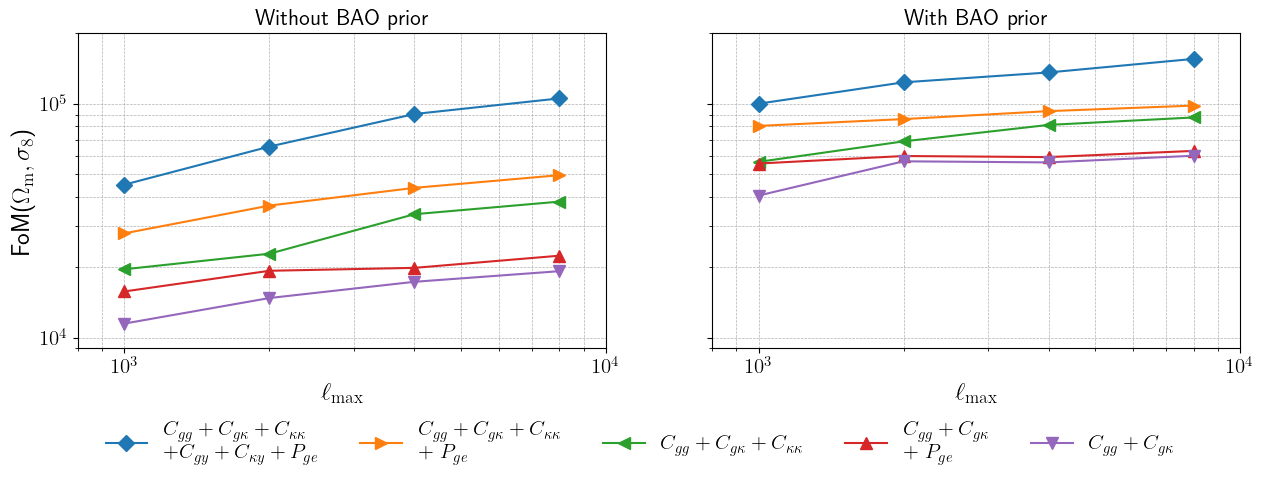

In [10]:
import matplotlib.pyplot as plt
import os

# --- Assumed Inputs ---
# These variables are the output from the data processing script.
# LMAX_ARRAY = [1000, 2000, 4000, 8000]
# final_foms = { ... }

# --- Plotting Configuration ---

PLOT_CONFIG = [
    {
        "key": "FoM_all_probes_all",
        "style": "D-",
        "label": r"$C_{gg} + C_{g\kappa} + C_{\kappa \kappa}$" + "\n" + r"$+ C_{gy} + C_{\kappa y} + P_{ge}$",
        "panel": 0,
        "title": "With Shear Terms"
    },
    {
        "key": "FoM_all_notSZ",
        "style": ">-",
        "label": r"$C_{gg} + C_{g\kappa} + C_{\kappa \kappa}$" + "\n" + r"+ $P_{ge}$",
        "panel": 0
    },
    {
        "key": "FoM_all_notSZ_nokSZ",
        "style": "<-",
        "label": r"$C_{gg} + C_{g \kappa} + C_{\kappa \kappa}$",
        "panel": 0
    },
    {
        "key": "FoM_all_noshear",
        "style": "^-",
        "label": r"$C_{gg} + C_{g \kappa}$" + "\n" + r"+ $P_{ge}$",
        "panel": 0,
        "title": "Without Shear Terms"
    },
    {
        "key": "FoM_all_noshear_nokSZ",
        "style": "v-",
        "label": r"$C_{gg} + C_{g\kappa}$",
        "panel": 0
    },
]

# --- Plot Generation ---

# Create a figure with 1 row, 2 columns of subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

# Loop through the configuration to plot each line on its specified panel
for item in PLOT_CONFIG:
    for panel_index in range(2):
        # panel_index = item["panel"]
        ax = axes[panel_index]
        if panel_index == 0:
            try:
                toplot = final_foms[item["key"]]
            except:
                toplot = np.zeros_like(LMAX_ARRAY)
            ax.set_title('Without BAO prior', fontsize=16)

        else:
            try:
                toplot = final_foms_wbao[item["key"]]
            except:
                toplot = np.zeros_like(LMAX_ARRAY)
            ax.set_title('With BAO prior', fontsize=16)
        ax.plot(
            LMAX_ARRAY,
            toplot,
            item["style"],
            ms=8.0,
            label=item["label"]
        )

# --- Plot Styling and Finalization ---

# Apply common settings to both subplots
for ax in axes:
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(800, 1e4)
    ax.set_xlabel(r"$\ell_{\rm max}$", fontsize=18)
    ax.grid(which="both", linestyle="--", linewidth=0.5)
    ax.tick_params(axis="both", which="major", labelsize=15)

# Set the shared y-axis label
axes[0].set_ylabel(r"FoM($\Omega_{\rm m}, \sigma_8$)", fontsize=18)
axes[0].set_ylim(9e3, 2e5)

# --- Create a single, shared legend below the plots ---
handles, labels = [], []
# for ax in axes[0]:
h, l = axes[0].get_legend_handles_labels()
handles.extend(h)
labels.extend(l)

fig.legend(
    handles, 
    labels, 
    loc='lower center',             # Position the legend at the bottom center
    bbox_to_anchor=(0.5, -0.02),    # Anchor it slightly below the plot area
    frameon=False, 
    fontsize=15,
    ncol=len(handles)               # Set number of columns to match items, creating a single row
)

# Adjust subplot layout to make room for the bottom legend
fig.subplots_adjust(bottom=0.25)

# --- Save the Figure ---
sdir = "/projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/plots/"
os.makedirs(sdir, exist_ok=True)
plt.savefig(os.path.join(sdir, "fom_comparison_wbao.pdf"), bbox_inches="tight")

plt.show()




[np.float64(19618.68149062077), np.float64(22865.297545723588), np.float64(33732.7065754894), np.float64(38180.54565600558)]
[np.float64(27937.452342898006), np.float64(36723.38241335244), np.float64(43723.315646883355), np.float64(49544.34412591002)]
[np.float64(45128.53434542064), np.float64(65657.62032686397), np.float64(90453.67760820921), np.float64(105483.51469325305)]


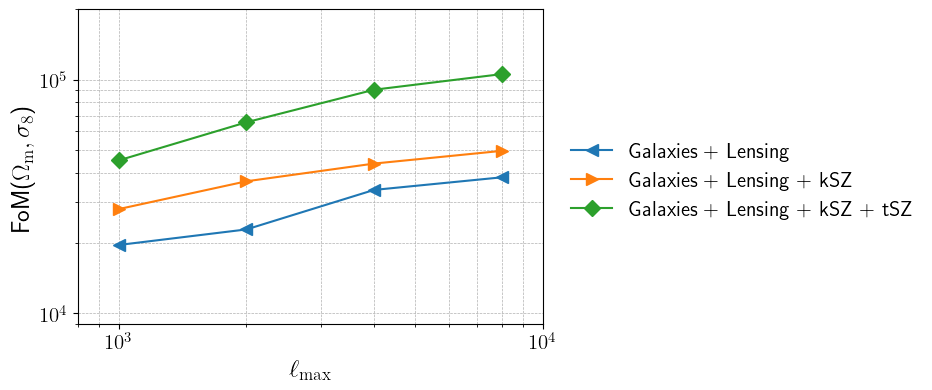

In [11]:
import matplotlib.pyplot as plt
import os

# --- Assumed Inputs ---
# These variables are the output from the data processing script.
# LMAX_ARRAY = [1000, 2000, 4000, 8000]
# final_foms = { ... }

# --- Plotting Configuration ---

PLOT_CONFIG = [
    {
        "key": "FoM_all_notSZ_nokSZ",
        "style": "<-",
        # "label": r"$C_{gg} + C_{g \kappa} + C_{\kappa \kappa}$",
        "label": r"Galaxies + Lensing",
        "color": "tab:blue",
        "panel": 0
    },   
    {
        "key": "FoM_all_notSZ",
        "style": ">-",
        # "label": r"$C_{gg} + C_{g\kappa} + C_{\kappa \kappa}$" + "\n" + r"+ $P_{ge}$",
        "label": r"Galaxies + Lensing + kSZ",  
        "color": "tab:orange",   
        "panel": 0
    },     
    {
        "key": "FoM_all_probes_all",
        "style": "D-",
        # "label": r"$C_{gg} + C_{g\kappa} + C_{\kappa \kappa}$" + "\n" + r"$+ C_{gy} + C_{\kappa y} + P_{ge}$",
         "label": r"Galaxies + Lensing + kSZ + tSZ",            
        "panel": 0,
        "color": "tab:red",
        "title": "With Shear Terms"
    }
    # {
    #     "key": "FoM_all_noshear",
    #     "style": "^-",
    #     "label": r"$C_{gg} + C_{g \kappa}$" + "\n" + r"+ $P_{ge}$",
    #     "panel": 0,
    #     "title": "Without Shear Terms"
    # },
    # {
    #     "key": "FoM_all_noshear_nokSZ",
    #     "style": "v-",
    #     "label": r"$C_{gg} + C_{g\kappa}$",
    #     "panel": 0
    # },
]

# --- Plot Generation ---

# Create a figure with 1 row, 2 columns of subplots
fig, ax = plt.subplots(1, 1, figsize=(6, 5), sharey=True)

# Loop through the configuration to plot each line on its specified panel
for item in PLOT_CONFIG:
    for panel_index in range(1):
        # panel_index = item["panel"]
        # ax = axes[panel_index]
        if panel_index == 0:
            # try:
            toplot = final_foms[item["key"]]
            # ax.set_title('Without BAO prior', fontsize=16)
        else:
            # try:
            toplot = final_foms_wbao[item["key"]]
            # except:
                # toplot = np.zeros_like(LMAX_ARRAY)
        print(toplot)
            # ax.set_title('With BAO prior', fontsize=16)
        ax.plot(
            LMAX_ARRAY,
            toplot,
            item["style"],
            ms=8.0,
            label=item["label"]
        )

# --- Plot Styling and Finalization ---

# Apply common settings to both subplots
# for ax in axes:
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(800, 1e4)
ax.set_xlabel(r"$\ell_{\rm max}$", fontsize=18)
ax.grid(which="both", linestyle="--", linewidth=0.5)
ax.tick_params(axis="both", which="major", labelsize=15)

# Set the shared y-axis label
ax.set_ylabel(r"FoM($\Omega_{\rm m}, \sigma_8$)", fontsize=18)
ax.set_ylim(9e3, 2e5)

# --- Create a single, shared legend below the plots ---
handles, labels = [], []
# for ax in axes[0]:
h, l = ax.get_legend_handles_labels()
handles.extend(h)
labels.extend(l)

fig.legend(
    handles, 
    labels, 
    loc='upper right',             # Position the legend at the bottom center
    bbox_to_anchor=(1.55, 0.65),    # Anchor it slightly below the plot area
    frameon=False, 
    fontsize=15,
    ncol=1              # Set number of columns to match items, creating a single row
)

# Adjust subplot layout to make room for the bottom legend
fig.subplots_adjust(bottom=0.25)

# --- Save the Figure ---
sdir = "/projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/plots/"
os.makedirs(sdir, exist_ok=True)
plt.savefig(os.path.join(sdir, "fom_comparison_proposal.pdf"), bbox_inches="tight")

plt.show()




In [29]:
# params = ['Om0', 'theta_ej_0', 'nu_theta_ej_M',  'nu_theta_ej_z',  'mu_beta','A_IA', 'eta_IA', 'sigma8', 'alpha_ky', 'S8']
# params = ['Om0','A_IA', 'eta_IA', 'sigma8',  'S8', 'h', 'ns', 'Ob0','mult_shear_bias_array_3',  'Delta_z_bias_array_3']
g = plots.getSinglePlotter(width_inch=9.0, ratio=1.0)
# g.settings.auto_ticks = True
g.settings.axes_fontsize   = 18
g.settings.lab_fontsize    = 20
g.settings.legend_fontsize = 20
g.settings.axis_marker_lw = 1.5
g.settings.num_plot_contours = 2

line_args = [{'lw':1.0,'color':'black'},{'lw':1.0, 'ls':'--' ,'color':'blue'},{'lw':1.0,'color':'red'},{'lw':0.1,'color':'orange'},{'lw':0.1,'color':'green'}]

contour_args = {'filled': True, 'alpha': 0.7}

# acorr_min = 0.06
# acorr_max = 0.1

acorr_min = 0.05
acorr_max = 0.1

probe = 'ky_kk_gg_gy_gk_ge'
lmax = 8000
# samps_8000, FoM_lmax = get_MC_samps_FoM(ldir + f'/{probe}/mcmc_v5_{probe}_scval_{lmax}_samples_4000_warmup_3000_num_chains_96_treedepth_4.pkl')        
samps_8000, FoM_lmax = get_MC_samps_FoM(ldir + f'/{probe}/mcmc_v5_{probe}_scval_{lmax}_samples_6000_warmup_6000_num_chains_96_treedepth_4.pkl')        
print(FoM_lmax)


lmax = 8000
# samps_4000, FoM_lmax = get_MC_samps_FoM(ldir + f'/{probe}/mcmc_v5_{probe}_scval_{lmax}_samples_4000_warmup_3000_num_chains_96_treedepth_4_wbaoprior_True.pkl', acorr_min=acorr_min, acorr_max = acorr_max)        
samps_4000, FoM_lmax = get_MC_samps_FoM(ldir + f'/{probe}/mcmc_v5_{probe}_scval_{lmax}_samples_4000_warmup_3000_num_chains_96_treedepth_4_init_value.pkl')        
# samps_4000, FoM_lmax = get_MC_samps_FoM(ldir + f'/{probe}/mcmc_v5_{probe}_scval_{lmax}_samples_6000_warmup_6000_num_chains_96_treedepth_4.pkl', ind_frac_rm = 0.5)        
print(FoM_lmax)

params = samps_8000.getParamNames().getRunningNames()
# g = plots.get_subplot_plotter(width_inch=8)
g.triangle_plot([samps_8000, samps_4000], ['sigma8', 'Om0', 'theta_ej_0', 'nu_theta_ej_M'], line_args=line_args, 
            contour_lws=[1.5, 1.5, 1.0], filled = [False, False,True, True, True], contour_colors = ['black','blue','red','orange','green'],
            ls=['-','--','','',''], legend_labels = [r'$C^{gg}_{\ell} + C^{g\kappa}_{\ell} + C^{\kappa \kappa}_{\ell} + P^{ge} + C^{\kappa y}_{\ell} + C^{gy}_{\ell}$',
                                                        r'$C^{gg}_{\ell} + C^{g\kappa}_{\ell} + C^{\kappa \kappa}_{\ell} + P^{ge}$',
                                                        r'$C^{gg}_{\ell} + C^{g\kappa}_{\ell} + C^{\kappa \kappa}_{\ell}$'])
# save_plot_dir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
# g.export(save_plot_dir  + 'contour_Om0_S8_nuejM_internal.pdf')
import matplotlib
%matplotlib inline
pl.show()






Removed no burn in
74553.18809935977


ValueError: cannot reshape array of size 0 into shape (0,newaxis)

<Figure size 900x900 with 0 Axes>

In [5]:
ldir = '/projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/chains_Apr_v2/'
lmax = 4000

probe = 'ky_kk_gg_gy_gk_ge'
chain_all, FoM_lmax = get_MC_samps_FoM(ldir + f'/{probe}/mcmc_v2_{probe}_scval_{lmax}_samples_3000_warmup_2000_num_chains_96_treedepth_4.pkl')    

probe = 'kk_gg_gk_ge'
chain_wkSZ, FoM_lmax = get_MC_samps_FoM(ldir + f'/{probe}/mcmc_v2_{probe}_scval_{lmax}_samples_3000_warmup_2000_num_chains_96_treedepth_4.pkl')    

probe = 'kk_gg_gk'
chain_nokSZ, FoM_lmax = get_MC_samps_FoM(ldir + f'/{probe}/mcmc_v2_{probe}_scval_{lmax}_samples_3000_warmup_2000_num_chains_96_treedepth_4.pkl')    



Removed no burn in
Removed no burn in
Removed no burn in


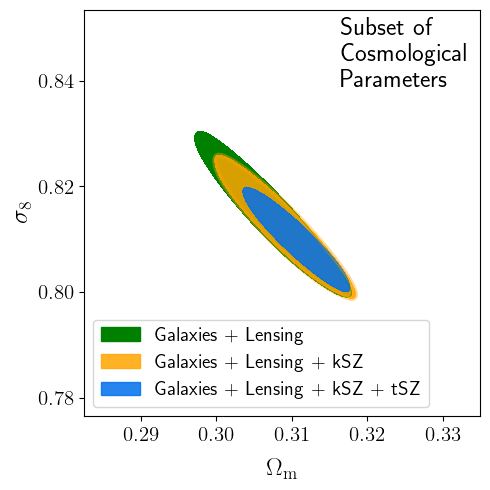

In [21]:
g = plots.getSinglePlotter(width_inch=5, ratio=1.0)
# g.settings.auto_ticks = True
g.settings.axes_fontsize   = 15
g.settings.lab_fontsize    = 18
g.settings.legend_fontsize = 18
g.settings.axis_marker_lw = 1.5
g.settings.num_plot_contours = 1

line_args = [{'lw':0.1,'color':'green'},{'lw':2.5,'color':'orange'}]
all_samples = [chain_nokSZ, chain_wkSZ, chain_all]
g.plot_2d(all_samples,'Om0', 'sigma8', 
          line_args=line_args,contour_lws=[1.5],  filled = [True, True, True], contour_colors = ['green','orange']
          ,ls=['','','','',''] )
        #   ,lims=[0.284, 0.346, 0.77, 0.9])  
g.add_legend([r'Galaxies + Lensing', r'Galaxies + Lensing + kSZ', r'Galaxies + Lensing + kSZ + tSZ'], legend_loc='lower left', fontsize=14)
g.add_text('Subset of' + '\n' + 'Cosmological' + '\n' + 'Parameters', x=0.65, y=0.89, fontsize=18, horizontalalignment='left')
sdir = '/projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/plots/'
g.export(fname = sdir+'cosmo_directcal.pdf')
# g.export(fname = '/mnt/home/spandey/ceph/GODMAX/notebooks/plots/Om_sig8_forecast_all_FINALSET.pdf')



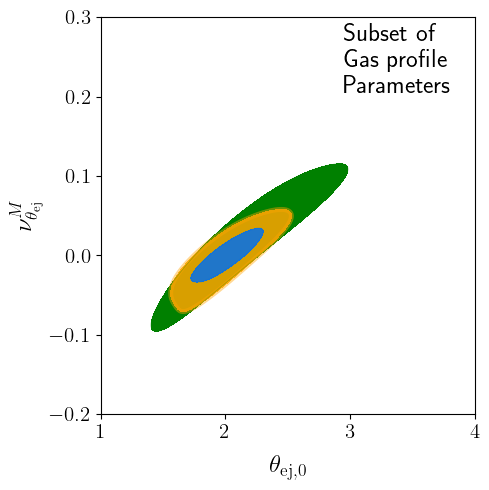

In [22]:
g = plots.getSinglePlotter(width_inch=5, ratio=1.0)
# g.settings.auto_ticks = True
g.settings.axes_fontsize   = 15
g.settings.lab_fontsize    = 18
g.settings.legend_fontsize = 18
g.settings.axis_marker_lw = 1.5
g.settings.num_plot_contours = 1

line_args = [{'lw':0.1,'color':'green'},{'lw':2.5,'color':'orange'}]
all_samples = [chain_nokSZ, chain_wkSZ, chain_all]
g.plot_2d(all_samples,'theta_ej_0', 'nu_theta_ej_M', 
          line_args=line_args,contour_lws=[1.5],  filled = [True, True, True], contour_colors = ['green','orange']
          ,ls=['','','','',''] 
        #    ,lims=[-18, 22, -1.5, 2])  
           ,lims=[1, 4, -0.2, 0.3])             
# g.add_legend([r'Galaxies + Lensing', r'Galaxies + Lensing + kSZ'], legend_loc='lower left', fontsize=14)
g.add_text('Subset of' + '\n' + 'Gas profile   ' + '\n' + 'Parameters',  x=0.65, y=0.89, fontsize=18, horizontalalignment='left')
g.export(fname = sdir+'gas_prof_directcal.pdf')



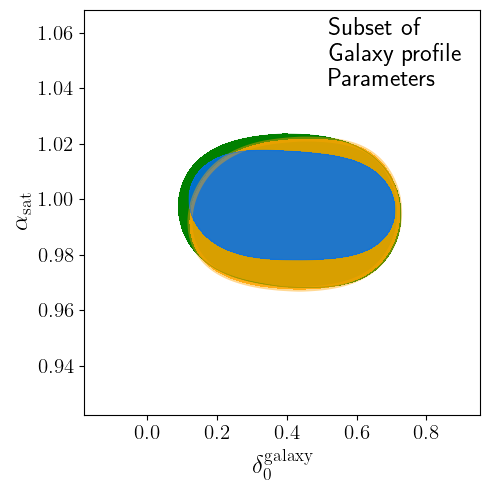

In [24]:
g = plots.getSinglePlotter(width_inch=5, ratio=1.0)
# g.settings.auto_ticks = True
g.settings.axes_fontsize   = 15
g.settings.lab_fontsize    = 18
g.settings.legend_fontsize = 18
g.settings.axis_marker_lw = 1.5
g.settings.num_plot_contours = 1

line_args = [{'lw':0.1,'color':'green'},{'lw':2.5,'color':'orange'}]
all_samples = [chain_nokSZ, chain_wkSZ, chain_all]
# g.plot_2d(all_samples,'beta_fshmr', 'alphasat_Nsat', 
g.plot_2d(all_samples,'delta_fshmr', 'alphasat_Nsat', 
          line_args=line_args,contour_lws=[1.5],  filled = [True, True, True], contour_colors = ['green','orange']
          ,ls=['','','','',''] )  
g.add_text('Subset of' + '\n' 'Galaxy profile   ' + '\n' + 'Parameters',  x=0.62, y=0.89, fontsize=18, horizontalalignment='left')        
# g.add_legend([r'Galaxies + Lensing', r'Galaxies + Lensing + kSZ'], legend_loc='lower left', fontsize=14)
g.export(fname = sdir+'gal_prof_directcal.pdf')




In [4]:
import jax.numpy as jnp
ldir = '/projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/chains_july_v5/'

probe = 'kk_gg_gk_ge'
lmax = 8000
fname = ldir + f'/{probe}/mcmc_v5_{probe}_scval_{lmax}_samples_6000_warmup_9000_num_chains_96_treedepth_4.pkl'
param_acorr='sigma8'
acorr_min=0.05
acorr_max = 0.15
nchains = 96
ind_frac_rm = 0.0
names=None
labels=None

# def get_MC_samps_FoM(fname, param_acorr='sigma8', acorr_min=0.035, acorr_max = 0.05, nchains = 96, ind_frac_rm = 0.0, names=None, labels=None):
df = pk.load(open(fname,'rb'))
sig8 = df[param_acorr]

sig8_rs = sig8.reshape(nchains,-1)
# print(sig8_rs.shape)
from numpyro.diagnostics import autocorrelation, autocovariance, gelman_rubin, effective_sample_size


# C) Calculate ESS for each chain using NumPyro
ess_per_chain = effective_sample_size(jnp.asarray(sig8_rs))

ess_thresh = 100
ind_del = []
for jc in range(nchains):
    ess_jc = effective_sample_size(jnp.asarray(sig8_rs)[jc,:][None,:])
    if ess_jc < ess_thresh:
        ind_del.append(jc)      

ind_del = np.array(ind_del)


In [12]:
# sig8_ess
print(sig8_rs.shape)
# ess_per_chain



(96, 6000)


In [15]:
# len(ind_del)


In [16]:
# acorr = autocorrelation(sig8_rs, axis=1)
# ind_del = []
# for ji in range(acorr.shape[0]):
#     if (np.std(acorr[ji,100:]) > acorr_max) or (np.std(acorr[ji,100:]) < acorr_min):
#         ind_del.append(ji)    

# sig8_std = np.std(sig8_rs, axis=-1)
# ind_del = np.where(sig8_std < 7e-3)[0]

samps = []
keys = []
for key in df:
    if ('base' not in key) and ('decentered' not in key):
        if key not in ['RUN_SETTINGS', 'diverging', 'potential_energy']:
        # if key not in ['prior_min', 'prior_max', 'fiducial_sims_params', 'fiducial_other_params', 'fiducial_halo_params', 'fiducial_analysis_params', 'diverging', 'potential_energy']:
            if ('Delta_z_bias_array' in key) or ('mult_shear_bias_array' in key):
                for jb in range(4):
                    samps.append(df[key][:, jb])
                    keys.append(key + '_' + str(jb))
                    # print(df[key][:, jb].shape)
            # print(samps[0].shape)
            # print(df[key].shape)
            else:
                samps.append(df[key])
                keys.append(key)

samps = np.array(samps).T
ind_sigma8 = keys.index('sigma8')
# ind_thetaejM = keys.index('nu_theta_ej_M')
ind_Om = keys.index('Om0')
samp_S8 = samps[:,ind_sigma8] * (samps[:,ind_Om]/0.3)**0.5

samps = np.concatenate([samps, samp_S8[:,None]], axis=1)
keys.append('S8')

import getdist
from getdist import plots, MCSamples

if names is None:
    names = keys
    indsel_names = np.arange(len(names))
else:
    indsel_names = []
    for name in names:
        indsel_names.append(keys.index(name))


save_plot_dir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
labels_all = {'A_IA':r'$A_{\rm IA}$',
 'Ob0':r'$\Omega_b$',
 'Om0':r'$\Omega_{\rm m}$',
 'eta_IA':r'$\eta_{\rm IA}$',
 'log10_Mc0':r'$\log(M_c)$',
 'theta_co_0':r'$\theta_{\rm co, 0}$',
 'gamma_rhogas':r'$\gamma$',
 'nu_z':r'$\nu_z$',
 'h':r'$h$',
 'ns':r'$n_s$',
 'mu_beta':r'$\mu_{\beta}$',
 'nu_theta_ej_M':r'$\nu^{M}_{\theta_{\rm ej}}$',
 'nu_theta_ej_z':r'$\nu^{z}_{\theta_{\rm ej}}$',
 'nu_theta_co_z':r'$\nu^{z}_{\theta_{\rm co}}$', 
 'log10_Mc0':r'$\log(M_c)$',
    'delta_rhogas':r'$\delta$',
    'gamma_rhogas':r'$\gamma$',
 'sigma8':r'$\sigma_8$',
 'theta_ej_0':r'$\theta_{\rm ej, 0}$',
 'S8':r'$S_8$',
 'alpha_nt':r'$\alpha_{\rm nt}$',
 'alpha_ky':r'$\alpha_{\rm ky}$',
 'alpha_kk':r'$\alpha_{\rm kk}$',
'Delta_z_bias_array_0':r'$\Delta z_1$',
 'Delta_z_bias_array_1':r'$\Delta z_2$',
 'Delta_z_bias_array_2':r'$\Delta z_3$',
 'Delta_z_bias_array_3':r'$\Delta z_4$',
 'mult_shear_bias_array_0':r'$m_1$',
 'mult_shear_bias_array_1':r'$m_2$',
 'mult_shear_bias_array_2':r'$m_3$',
 'mult_shear_bias_array_3':r'$m_4$',
'alphasat_Nsat':r'$\alpha_{\rm sat}$',
'beta_a_fshmr':r'$\beta^{\rm galaxy}_{\rm z}$',
'beta_fshmr':r'$\beta^{\rm galaxy}_{\rm 0}$',
'delta_a_fshmr':r'$\delta^{\rm galaxy}_{\rm z}$',
'delta_fshmr':r'$\delta^{\rm galaxy}_{\rm 0}$',
'log10M1_a_fshmr':r'$\log(M^{\rm galaxy}_1)_{\rm z}$',
'log10M1_fshmr':r'$\log(M^{\rm galaxy}_1)_{\rm 0}$',
'siglogMstar_Ncen':r'$\sigma_{\log M^{\rm galaxy}_{\star}}$',
}

if labels is None:
    labels = []
    
    for key in keys:
        if key in labels_all.keys():
            labels.append(labels_all[key])
        else:
            labels.append(r'm')


# nchains = 80
samps_sel = samps.reshape(nchains,-1, samps.shape[-1])
nsamp_per_chain = samps_sel.shape[1]
nrm = int(ind_frac_rm * nsamp_per_chain)
samps_sel = samps_sel[:, nrm:, :]

if len(ind_del) > 0:
    samps_sel = np.delete(samps_sel, ind_del, axis=0)
else:
    samps_sel = samps_sel

samps = samps_sel.reshape(-1, samps_sel.shape[-1])
# print(samps.shape, samps_sel.shape)
from numpyro.diagnostics import gelman_rubin, effective_sample_size, print_summary
ind_gr = ind_sigma8
gr = gelman_rubin(samps[:, ind_gr].reshape(samps_sel.shape[0], -1))
# print(gr)

samples = MCSamples(samples=samps[:,indsel_names],names = names, labels = labels)
# marge = samples.getMargeStats()
pars_all = samples.getParamNames().getRunningNames()
om_index = pars_all.index('Om0')
sig8_index = pars_all.index('sigma8')
FoM_Om_sig8 = 1/np.sqrt(np.linalg.det(samples.getCov(pars=[om_index,sig8_index])))
print(FoM_Om_sig8)
# return samples, FoM_Om_sig8


Removed no burn in
47367.00400104322


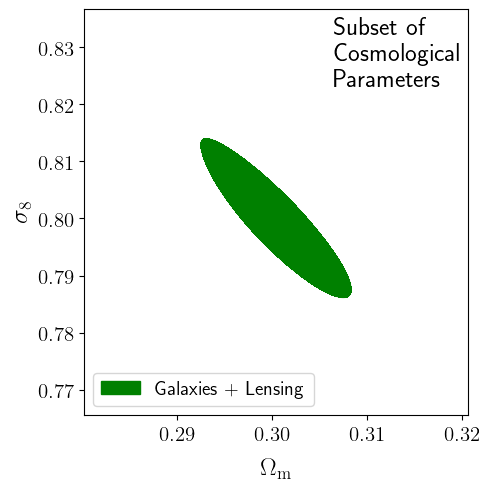

In [17]:
g = plots.getSinglePlotter(width_inch=5, ratio=1.0)
# g.settings.auto_ticks = True
g.settings.axes_fontsize   = 15
g.settings.lab_fontsize    = 18
g.settings.legend_fontsize = 18
g.settings.axis_marker_lw = 1.5
g.settings.num_plot_contours = 1

line_args = [{'lw':0.1,'color':'green'},{'lw':2.5,'color':'orange'}]
all_samples = [samples]
g.plot_2d(all_samples,'Om0', 'sigma8', 
          line_args=line_args,contour_lws=[1.5],  filled = [True, True, True], contour_colors = ['green','orange']
          ,ls=['','','','',''] )
        #   ,lims=[0.284, 0.346, 0.77, 0.9])  
g.add_legend([r'Galaxies + Lensing', r'Galaxies + Lensing + kSZ', r'Galaxies + Lensing + kSZ + tSZ'], legend_loc='lower left', fontsize=14)
g.add_text('Subset of' + '\n' + 'Cosmological' + '\n' + 'Parameters', x=0.65, y=0.89, fontsize=18, horizontalalignment='left')
sdir = '/projects/bdne/spandey3/Pge_GODMAX/GODMAX/results/pge/plots/'
# g.export(fname = sdir+'cosmo_directcal.pdf')
# g.export(fname = '/mnt/home/spandey/ceph/GODMAX/notebooks/plots/Om_sig8_forecast_all_FINALSET.pdf')




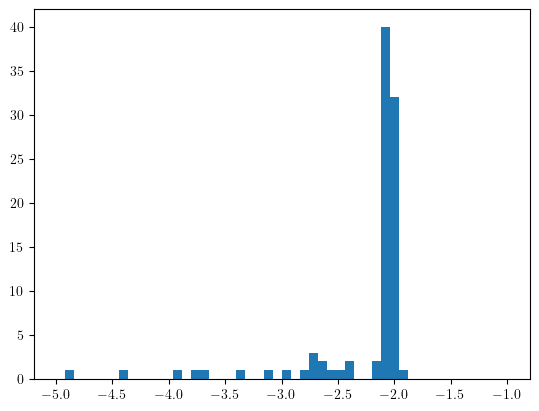

In [6]:
# pl.figure()
# pl.plot(acorr[0,1:] - acorr[0,:-1])
# pl.plot(acorr[3,1:] - acorr[3,:-1])
# fft_acorr0 = np.fft.fft(acorr[0,1:])
pl.figure()
_ = pl.hist(np.log10(np.std(sig8_rs, axis=-1)), bins=50, range=(-5,-1))




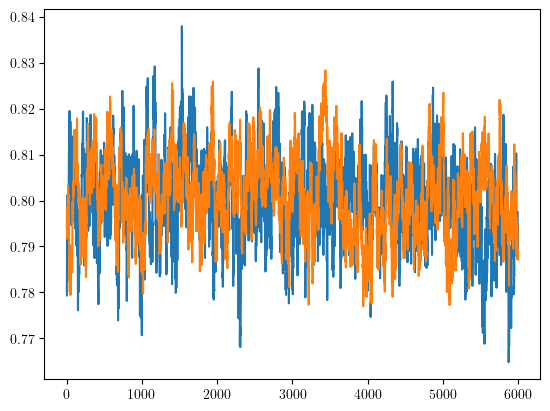

In [11]:
# np.abs(fft_acorr0)
pl.figure()
pl.plot(sig8_rs[0,:])
# pl.plot(sig8_rs[3,:])
pl.plot(sig8_rs[5,:])
# pl.plot(acorr[0,1:])
# pl.plot(acorr[1,1:])
# pl.plot(acorr[3,1:])
# pl.plot(np.abs(np.fft.rfft(acorr[0,1:])))
# pl.plot(np.abs(np.fft.rfft(acorr[3,1:])))
# pl.yscale('log')
